# Overview
Ten notebook jest przeznaczony do analizy algorytmów redukcji wymiarowości na zbiorze **iris**

https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html

Badamy następujace algorytmy:

- Linear Discriminant An


In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
from utils.scores import Dataset

iris = load_iris()
X = iris.data
y = iris.target
iris_dataset = Dataset(X, y, 'Iris')




## LDA 

In [ ]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
from utils.lda import my_lda
model_lda = my_lda(n_components=2)
X_lda, df_lda = model_lda.fit(X_scaled, y)

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_lda['LDA_1'], df_lda['LDA_2'], c=y, alpha=0.8)
plt.title("LDA na Iris")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

In [ ]:
from sklearn.manifold import trustworthiness

trust_lda = trustworthiness(X_scaled, X_lda, n_neighbors=5)
print(f"Trustworthiness dla LDA: {trust_lda:.4f}")

# PCA

In [ ]:
from utils.pca import my_pca

model_pca = my_pca(n_components=2)
X_pca, df_pca = model_pca.fit(X_scaled)

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_pca['PC_1'], df_pca['PC_2'], c=y, alpha=0.8)
plt.title("PCA na Iris")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

In [ ]:
trust_pca = trustworthiness(X_scaled, X_pca, n_neighbors=5)
print(f"Trustworthiness dla PCA: {trust_pca:.4f}")

## Kernel PCA

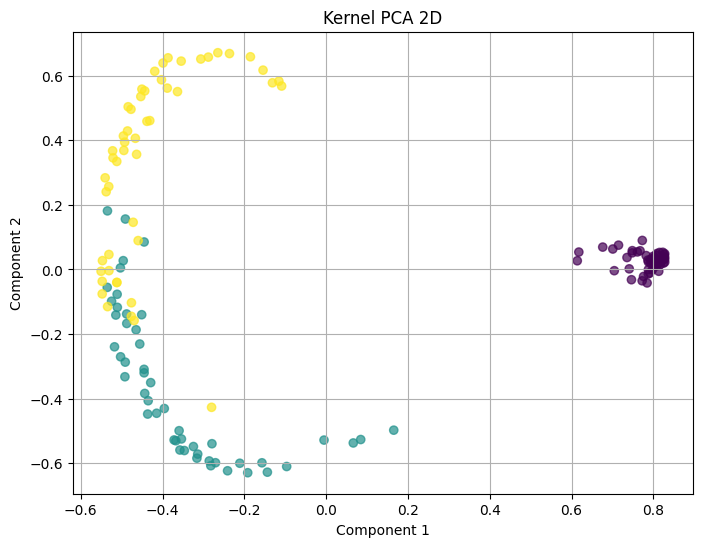

In [7]:
from sklearn.decomposition import PCA, KernelPCA

PCA_2d = KernelPCA(n_components=2, kernel='rbf')
X_pca_2d = PCA_2d.fit_transform(iris_dataset.X)
iris_dataset.plot_projection(X_pca_2d, title="Kernel PCA 2D")

In [ ]:
from sklearn.manifold import trustworthiness

trustworthiness(X, X_pca_2d, n_neighbors=5)

np.float64(0.9265164319248826)

## TSNE

In [ ]:
from utils.tsne import tsne
model_tsne = tsne(n_components=2, perplexity=30)
X_tsne = model_tsne.fit_transform(X_scaled)

In [ ]:
df_tsne = pd.DataFrame(
    X_tsne,
    columns=['TSNE_1', 'TSNE_2']
)

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_tsne['TSNE_1'], df_tsne['TSNE_2'], c=y, alpha=0.8)
plt.title("t-SNE na Iris")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
trust_tsne = trustworthiness(X_scaled, X_tsne, n_neighbors=5)
print(f"Trustworthiness dla t-SNE: {trust_tsne:.4f}")

## Autoencoder

In [ ]:
from utils.autoencoder import autoencoder

model_ae = Autoencoder(input_dim=X_scaled.shape[1], latent_dim=2)

model_ae.fit(X_scaled, epochs=200)
X_ae = model_ae.transform(X_scaled)

In [ ]:
df_ae = pd.DataFrame(X_ae, columns=["AE_1", "AE_2"])

In [ ]:
plt.scatter(df_ae["AE_1"], df_ae["AE_2"], c=y)
plt.title("Autoencoder na Iris")
plt.show()

In [ ]:
trust_ae = trustworthiness(X_scaled, X_ae, n_neighbors=5)
print(f"Trustworthiness dla Autoencodera: {trust_ae:.4f}")